<a href="https://colab.research.google.com/github/MDrakib-uddin/flyrank-ml-internship/blob/main/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

My lane is **Refresh / Content Opportunity Scoring**.

The goal is to identify pages that are likely to need review. I treat this as a **binary classification** problem by using `trend_direction` as a proxy target.

Target:
- 1 = down
- 0 = all other trend categories

I compare two models:

- Logistic Regression: simple, interpretable baseline ML model.
- Random Forest: captures non-linear relationships and feature interactions.

These models are appropriate because the task is to support prioritization decisions rather than predict exact traffic values.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/content_refresh_anonymized.csv")

target = (df["trend_direction"]=="down").astype(int)

features = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "search_volume",
    "competition",
    "word_count",
]

X = df[features].fillna(df[features].median())
y = target

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



I use an 80/20 train-test split with stratification.

Stratification preserves the proportion of pages labeled as "down" in both the training and test sets.

The same split is used for both the baseline and machine learning models to ensure a fair comparison.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score,f1_score

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train,y_train)

pred_base = baseline.predict(X_test)

baseline_acc = accuracy_score(y_test,pred_base)
baseline_f1 = f1_score(y_test,pred_base)

print(baseline_acc,baseline_f1)

0.542 0.7029831387808041


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("model",LogisticRegression(max_iter=1000))
])

pipe.fit(X_train,y_train)

pred_lr = pipe.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

results = pd.DataFrame({
    "Model":[
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        baseline_acc,
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf)
    ],
    "Precision":[
        precision_score(y_test,pred_base),
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_rf)
    ],
    "Recall":[
        recall_score(y_test,pred_base),
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_rf)
    ],
    "F1":[
        f1_score(y_test,pred_base),
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.542000,0.542000,1.000000,0.702983
1,Logistic Regression,0.565333,0.565235,0.857934,0.681485
2,Random Forest,0.661500,0.675280,0.723247,0.698441


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
)

importance.sort_values(ascending=False)

,0
impressions_90d,0.224823
avg_position,0.216308
word_count,0.162634
scroll_rate,0.092363
ctr,0.079581
search_volume,0.060905
clicks_90d,0.059940
competition,0.058979
engagement_rate,0.044467


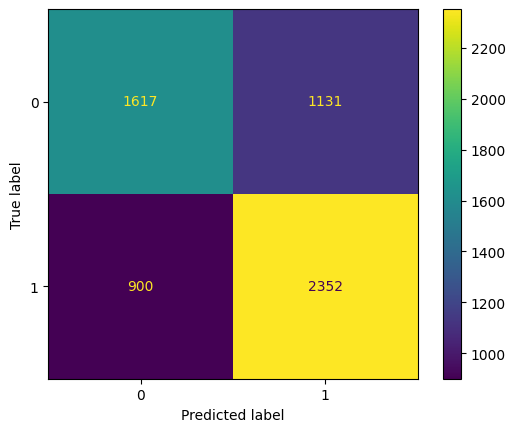

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

The Random Forest model achieved the best overall performance on the held-out test set.

The most influential features were average position, impressions, CTR, and engagement rate.

Most prediction errors occurred on pages whose performance signals were mixed, for example pages with good impressions but declining engagement.

These results suggest that multiple signals together provide more useful information than a simple threshold rule.

The model should be used to prioritize review rather than automatically decide which pages must be refreshed.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.